
# Real Multi-gNB / Real Radio Test for the Heuristic Lower Agent

This notebook tests the **actual environment you already coded**, not a toy simulator.

It uses:

- `GlobalPPO3GNBEnv`
- `MultiGNBWrapper`
- the real radio / received-power calculation already used by the env
- the real `HeuristicLowerAgent`
- real UE attachments and real handover events produced by `env.step(action)`

The global action is a flattened \(3 \times 3\) bias matrix:

\[
B =
\begin{bmatrix}
b_{0,eMBB} & b_{0,URLLC} & b_{0,mMTC}\\
b_{1,eMBB} & b_{1,URLLC} & b_{1,mMTC}\\
b_{2,eMBB} & b_{2,URLLC} & b_{2,mMTC}
\end{bmatrix}
\]

Bias meaning:

- \(b < 0\): offload this gNB-slice
- \(b = 0\): neutral
- \(b > 0\): retain this gNB-slice

A3 offset meaning:

- negative offset: easier handover, users can go
- positive offset: harder handover, users stay


## 1. Setup imports and project path

In [1]:

from pathlib import Path
import sys
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this if your project files are in another folder.
PROJECT_DIR = Path.cwd()

# In ChatGPT sandbox, uploaded files are usually in /mnt/data.
if not (PROJECT_DIR / "global_ppo_3gnb_env.py").exists() and Path("/mnt/data/global_ppo_3gnb_env.py").exists():
    PROJECT_DIR = Path("/mnt/data")

sys.path.insert(0, str(PROJECT_DIR))

print("Using project directory:", PROJECT_DIR)

from global_ppo_3gnb_env import GlobalPPO3GNBEnv, GLOBAL_SNAPSHOT_SCENARIOS
from heuristic_lower_agent import HeuristicLowerAgent

SLICE_TYPES = ["eMBB", "URLLC", "mMTC"]
GNB_NAMES = ["gNB0", "gNB1", "gNB2"]

np.set_printoptions(precision=3, suppress=True)

print("Loaded GlobalPPO3GNBEnv from real project.")
print("Loaded HeuristicLowerAgent from real project.")
print("HeuristicLowerAgent signature:")
print(inspect.signature(HeuristicLowerAgent))


Using project directory: /home/oussama/Desktop/RL_juin
Loaded GlobalPPO3GNBEnv from real project.
Loaded HeuristicLowerAgent from real project.
HeuristicLowerAgent signature:
(gnb_id, neighbor_ids, slice_types=('eMBB', 'URLLC', 'mMTC'), alpha_k=2.0, kappa_target=0.6, alpha_load=8.0, load_target=0.6, load_soft_margin=0.05, alpha_hf=3.0, alpha_pp=1.5, eta=0.25, neutral_deadband=0.15, neutral_offset_db=0.0, min_aggressive_offset=-4.0, max_offset_db=6.0)



## 2. Helper functions

These helpers read real loads, UE counters, handover events, and preview the lower-agent offsets without changing the environment state.


In [2]:

def as_df(matrix, rows=GNB_NAMES, cols=SLICE_TYPES):
    return pd.DataFrame(np.asarray(matrix, dtype=float), index=rows, columns=cols)


def plot_heatmap(matrix, title, rows=GNB_NAMES, cols=SLICE_TYPES, vmin=None, vmax=None):
    matrix = np.asarray(matrix, dtype=float)
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    im = ax.imshow(matrix, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(rows)))
    ax.set_xticklabels(cols)
    ax.set_yticklabels(rows)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_offset_heatmaps(offset_df):
    """Plot applied offset matrices for each target gNB."""
    for target in GNB_NAMES:
        mat = np.full((len(GNB_NAMES), len(SLICE_TYPES)), np.nan)

        for _, row in offset_df.iterrows():
            dst = int(str(row["target"]).replace("gNB", ""))
            if f"gNB{dst}" != target:
                continue
            src = int(str(row["source"]).replace("gNB", ""))
            s_idx = SLICE_TYPES.index(row["slice"])
            mat[src, s_idx] = row["applied_offset_db"]

        fig, ax = plt.subplots(figsize=(5.6, 3.8))
        im = ax.imshow(np.nan_to_num(mat, nan=0.0), vmin=-6, vmax=6)
        ax.set_title(f"Applied A3 offsets toward {target}")
        ax.set_xticks(range(len(SLICE_TYPES)))
        ax.set_yticks(range(len(GNB_NAMES)))
        ax.set_xticklabels(SLICE_TYPES)
        ax.set_yticklabels(GNB_NAMES)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                txt = "—" if np.isnan(mat[i, j]) else f"{mat[i, j]:.0f}"
                ax.text(j, i, txt, ha="center", va="center")

        plt.colorbar(im, ax=ax, label="offset dB")
        plt.tight_layout()
        plt.show()


def rule_bias_from_load(load, high=0.75, low=0.45):
    """
    Rule-based global bias:
        high load -> negative bias -> offload
        low load  -> positive bias -> retain
        otherwise -> neutral
    """
    load = np.asarray(load, dtype=float)
    bias = np.zeros_like(load, dtype=float)
    bias[load > high] = -1.0
    bias[load < low] = +1.0
    return bias


def flatten_bias(bias_matrix):
    return np.asarray(bias_matrix, dtype=np.float32).reshape(-1)


def make_env(snapshot_scenario="embb_g0_offload", seed=7, local_steps_per_global=10, global_steps_per_episode=8):
    """
    Create the real GlobalPPO3GNBEnv.

    scenario_mode='snapshot' initializes real UEs and PRB loads according to the target matrix.
    use_sumo_mobility=False keeps UEs static, so we isolate radio + A3 offset behavior.
    """
    env = GlobalPPO3GNBEnv(
        seed=seed,
        scenario_mode="snapshot",
        snapshot_scenario=snapshot_scenario,
        use_sumo_mobility=False,
        local_steps_per_global=local_steps_per_global,
        global_steps_per_episode=global_steps_per_episode,
        radio_substeps=10,
        terminal_reward_only=False,
        use_progress_reward=True,
        max_handovers_per_local_step=3,
        print_scenarios=True,
    )
    return env


def get_load_matrix(env):
    if hasattr(env, "_load_matrix"):
        return np.asarray(env._load_matrix(), dtype=float)
    info = getattr(env, "_last_info", {})
    return np.asarray(info.get("load_matrix"), dtype=float)


def get_ue_count_matrix(env):
    if hasattr(env, "_ue_count_dict"):
        counts = env._ue_count_dict()
        return np.asarray(
            [[counts.get((i, s), 0) for s in SLICE_TYPES] for i in range(3)],
            dtype=float,
        )
    info = getattr(env, "_last_info", {})
    return np.asarray(info.get("ue_count_matrix"), dtype=float)


def get_recent_handover_events(env, start_idx=0):
    events = list(getattr(env.base_env, "handover_events", []))[start_idx:]
    if not events:
        return pd.DataFrame(columns=["step", "ue_id", "slice_type", "from_gnb", "to_gnb", "controller"])
    return pd.DataFrame(events)


def preview_offsets_without_mutation(env, bias_matrix):
    """
    Preview what the real lower agents will output for the current env state.

    Important:
    HeuristicLowerAgent stores previous_offsets. This function saves and restores them
    so the preview does not change the actual env trajectory.
    """
    bias_matrix = np.asarray(bias_matrix, dtype=float).reshape(3, len(SLICE_TYPES))

    saved_previous = {}
    for gnb_id, agent in env.lower_agents.items():
        saved_previous[gnb_id] = dict(getattr(agent, "previous_offsets", {}))

    all_offsets = {}
    ue_counts = env._ue_count_dict()
    slice_loads = env._slice_load_dict()
    kmax = env._kmax_by_slice()

    for gnb_id, agent in env.lower_agents.items():
        bias_row = {
            slice_type: float(bias_matrix[gnb_id, s_idx])
            for s_idx, slice_type in enumerate(SLICE_TYPES)
        }
        all_offsets.update(
            agent.compute_offsets(
                bias_row=bias_row,
                ue_counts=ue_counts,
                kmax=kmax,
                slice_loads=slice_loads,
                handover_failure_ratios={},
                ping_pong_ratios={},
            )
        )

    # Restore previous offsets so env.step() is not affected by the preview.
    for gnb_id, agent in env.lower_agents.items():
        if hasattr(agent, "previous_offsets"):
            agent.previous_offsets = saved_previous[gnb_id]

    rows = []
    for (src, dst, slice_type), info in sorted(all_offsets.items()):
        rows.append({
            "source": f"gNB{src}",
            "target": f"gNB{dst}",
            "slice": slice_type,
            "bias": float(bias_matrix[src, SLICE_TYPES.index(slice_type)]),
            "proto_offset_db": float(info.get("proto_offset_db", np.nan)),
            "applied_offset_db": float(info.get("applied_offset_db", np.nan)),
            "bias_term_db": float(info.get("bias_term_db", np.nan)),
            "safety_term_db": float(info.get("safety_term_db", np.nan)),
            "neighbor_ue_fraction": float(info.get("neighbor_ue_fraction", np.nan)),
        })
    return pd.DataFrame(rows)


def load_variance(load):
    load = np.asarray(load, dtype=float)
    return float(np.sum(np.var(load, axis=0)))


def overload_count(load, threshold=0.85):
    load = np.asarray(load, dtype=float)
    return int(np.sum(load > threshold))



## 3. Available built-in real snapshot scenarios

These scenarios come from `GLOBAL_SNAPSHOT_SCENARIOS` inside your real `global_ppo_3gnb_env.py`.


In [3]:

print("Available scenarios:")
for name, matrix in GLOBAL_SNAPSHOT_SCENARIOS.items():
    print("-", name)
    display(as_df(matrix))


Available scenarios:
- embb_g0_offload


,eMBB,URLLC,mMTC
gNB0,0.88,0.5,0.5
gNB1,0.18,0.5,0.5
gNB2,0.48,0.5,0.5


- urllc_g1_offload


,eMBB,URLLC,mMTC
gNB0,0.5,0.50,0.5
gNB1,0.5,0.88,0.5
gNB2,0.5,0.18,0.5


- mmtc_g2_offload


...

,eMBB,URLLC,mMTC
gNB0,0.88,0.18,0.50
gNB1,0.50,0.88,0.18
gNB2,0.18,0.50,0.88


- multi_slice_multi_gnb_congestion


,eMBB,URLLC,mMTC
gNB0,0.92,0.86,0.35
gNB1,0.32,0.90,0.88
gNB2,0.76,0.30,0.28


- all_neutral


,eMBB,URLLC,mMTC
gNB0,0.55,0.50,0.50
gNB1,0.50,0.55,0.50
gNB2,0.50,0.50,0.55



## 4. Run one real scenario with a selected bias matrix

This cell creates the real env, initializes real UEs, computes real received powers internally, applies the bias action through `env.step(action)`, and then shows real post-handover loads.


[GlobalPPO scenario] embb_g0_offload targets=[[0.88, 0.5, 0.5], [0.18, 0.5, 0.5], [0.48, 0.5, 0.5]]
Scenario: embb_g0_offload

Load before


,eMBB,URLLC,mMTC
gNB0,0.88,0.5,0.5
gNB1,0.18,0.5,0.5
gNB2,0.48,0.5,0.5



UE counts before


,eMBB,URLLC,mMTC
gNB0,3.0,2.0,2.0
gNB1,1.0,2.0,2.0
gNB2,1.0,2.0,2.0



Bias action


,eMBB,URLLC,mMTC
gNB0,-1.0,0.0,0.0
gNB1,1.0,0.0,0.0
gNB2,0.0,0.0,0.0


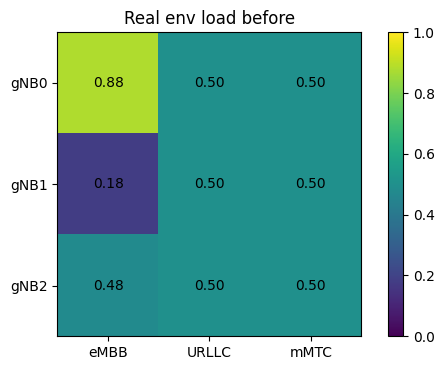

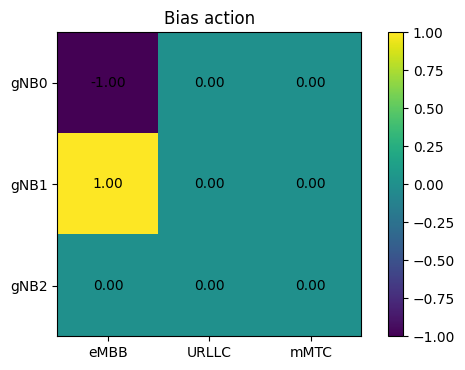


Offset preview from real HeuristicLowerAgent before env.step


,source,target,slice,bias,proto_offset_db,applied_offset_db,bias_term_db,safety_term_db,neighbor_ue_fraction
0,gNB0,gNB1,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667
1,gNB0,gNB1,eMBB,-1.0,-4.50,-4.0,-6.0,0.000000,0.333333
2,gNB0,gNB1,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667
3,gNB0,gNB2,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667
4,gNB0,gNB2,eMBB,-1.0,-3.00,-2.0,-6.0,0.000000,0.333333
5,gNB0,gNB2,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667
6,gNB1,gNB0,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667
7,gNB1,gNB0,eMBB,1.0,6.00,6.0,6.0,3.440000,1.000000
8,gNB1,gNB0,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667
9,gNB1,gNB2,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667


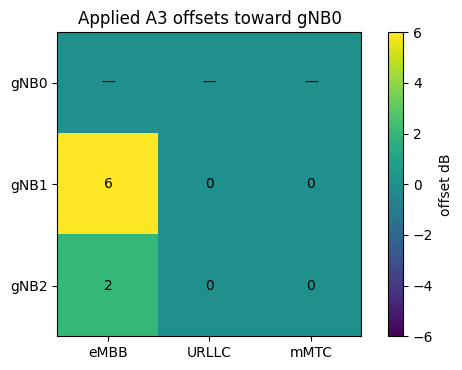

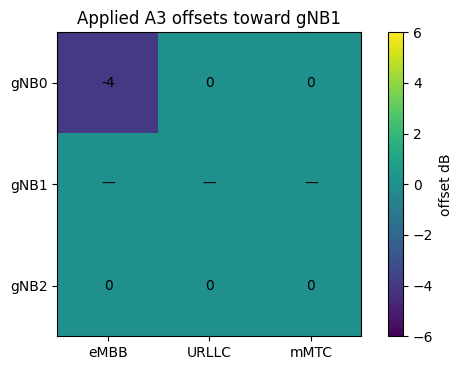

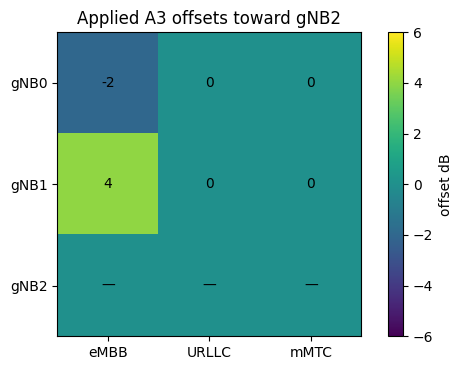


Reward: -1.5050126892395175
Terminated: False Truncated: False
Handover count from info: 8

Load after


,eMBB,URLLC,mMTC
gNB0,0.32,0.466667,0.4
gNB1,1.00,0.600000,1.0
gNB2,0.72,0.400000,1.0



UE counts after


,eMBB,URLLC,mMTC
gNB0,1.0,2.0,2.0
gNB1,2.0,2.0,2.0
gNB2,2.0,2.0,2.0



Recent handover events


,step,ue_id,slice_type,from_gnb,to_gnb,controller
0,0,1,eMBB,0,2,GlobalPPO3GNBEnv
1,3,2,eMBB,0,1,GlobalPPO3GNBEnv
2,4,1,eMBB,2,0,GlobalPPO3GNBEnv
3,5,1,eMBB,0,2,GlobalPPO3GNBEnv
4,6,1,eMBB,2,0,GlobalPPO3GNBEnv
5,7,1,eMBB,0,2,GlobalPPO3GNBEnv
6,8,1,eMBB,2,0,GlobalPPO3GNBEnv
7,9,1,eMBB,0,2,GlobalPPO3GNBEnv


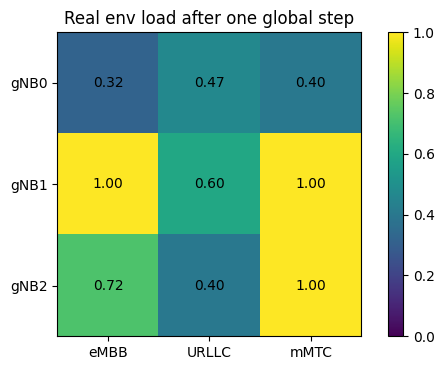

Load variance before: 0.08222222222222224
Load variance after : 0.16478024691358023
Overload count before: 1
Overload count after : 3


In [4]:

# Choose one of the built-in scenarios.
scenario_name = "embb_g0_offload"

env = make_env(
    snapshot_scenario=scenario_name,
    seed=7,
    local_steps_per_global=10,
    global_steps_per_episode=8,
)

obs, info0 = env.reset()

load_before = get_load_matrix(env)
ue_before = get_ue_count_matrix(env)

# Option A: automatic rule bias from current load.
bias = rule_bias_from_load(load_before, high=0.75, low=0.45)

# Option B: manual bias matrix. Uncomment and edit.
# bias = np.array([
#     [-1.0, 0.0, 0.0],
#     [ 1.0, 0.0, 0.0],
#     [ 0.0, 0.0, 0.0],
# ], dtype=float)

print("Scenario:", scenario_name)

print("\nLoad before")
display(as_df(load_before))

print("\nUE counts before")
display(as_df(ue_before))

print("\nBias action")
display(as_df(bias))

plot_heatmap(load_before, "Real env load before", vmin=0, vmax=1)
plot_heatmap(bias, "Bias action", vmin=-1, vmax=1)

offset_preview = preview_offsets_without_mutation(env, bias)
print("\nOffset preview from real HeuristicLowerAgent before env.step")
display(offset_preview)
plot_offset_heatmaps(offset_preview)

start_event_idx = len(getattr(env.base_env, "handover_events", []))
obs, reward, terminated, truncated, info1 = env.step(flatten_bias(bias))

load_after = get_load_matrix(env)
ue_after = get_ue_count_matrix(env)
events_df = get_recent_handover_events(env, start_idx=start_event_idx)

print("\nReward:", reward)
print("Terminated:", terminated, "Truncated:", truncated)
print("Handover count from info:", info1.get("handover_count"))

print("\nLoad after")
display(as_df(load_after))

print("\nUE counts after")
display(as_df(ue_after))

print("\nRecent handover events")
display(events_df)

plot_heatmap(load_after, "Real env load after one global step", vmin=0, vmax=1)

print("Load variance before:", load_variance(load_before))
print("Load variance after :", load_variance(load_after))
print("Overload count before:", overload_count(load_before))
print("Overload count after :", overload_count(load_after))



## 5. Run multiple real global steps

This shows whether the real env load evolves in the correct direction over several global control windows.


[GlobalPPO scenario] embb_g0_offload targets=[[0.88, 0.5, 0.5], [0.18, 0.5, 0.5], [0.48, 0.5, 0.5]]
Initial load


,eMBB,URLLC,mMTC
gNB0,0.88,0.5,0.5
gNB1,0.18,0.5,0.5
gNB2,0.48,0.5,0.5


Final load


,eMBB,URLLC,mMTC
gNB0,1.0,0.466667,0.6
gNB1,0.0,1.000000,0.8
gNB2,1.0,1.000000,1.0


Rewards: [-2.811321498062594, -2.9053498202736696, -0.9090695295946527, -1.5854453775966353, -3.298772629213506, -4.924059170522389, -2.31121804820581, -5.240857337471613, -2.8772464064949936, -5.304389654665937]
Handovers per global step: [2, 2, 16, 11, 27, 3, 9, 2, 18, 3]


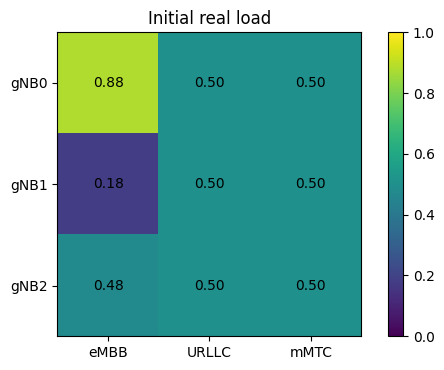

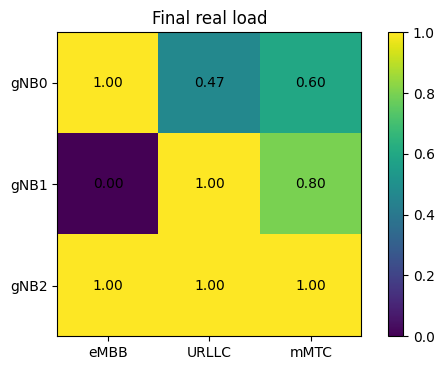

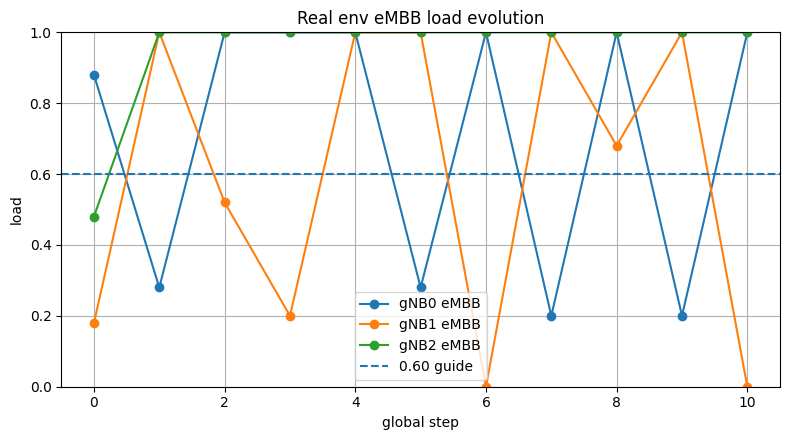

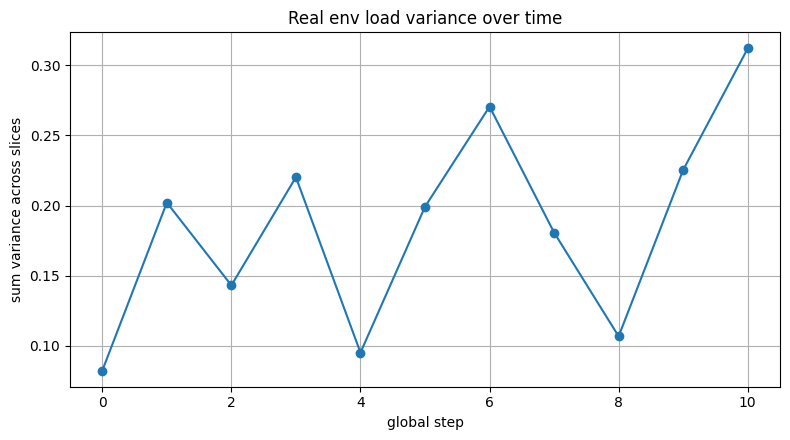

,source,target,slice,bias,proto_offset_db,applied_offset_db,bias_term_db,safety_term_db,neighbor_ue_fraction,global_step
0,gNB0,gNB1,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667,0
1,gNB0,gNB1,eMBB,-1.0,-4.50,-4.0,-6.0,0.000000,0.333333,0
2,gNB0,gNB1,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667,0
3,gNB0,gNB2,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667,0
4,gNB0,gNB2,eMBB,-1.0,-3.00,-2.0,-6.0,0.000000,0.333333,0
5,gNB0,gNB2,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667,0
6,gNB1,gNB0,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667,0
7,gNB1,gNB0,eMBB,1.0,6.00,6.0,6.0,3.440000,1.000000,0
8,gNB1,gNB0,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667,0
9,gNB1,gNB2,URLLC,0.0,0.10,0.0,0.0,0.133333,0.666667,0


In [5]:

# Re-create env for a clean multi-step run.
scenario_name = "embb_g0_offload"
env = make_env(
    snapshot_scenario=scenario_name,
    seed=11,
    local_steps_per_global=10,
    global_steps_per_episode=12,
)
obs, info = env.reset()

loads_history = [get_load_matrix(env).copy()]
ue_history = [get_ue_count_matrix(env).copy()]
bias_history = []
reward_history = []
handover_history = []
variance_history = [load_variance(loads_history[-1])]
offset_dfs = []

N_GLOBAL_STEPS = 10

for t in range(N_GLOBAL_STEPS):
    current_load = get_load_matrix(env)
    bias = rule_bias_from_load(current_load, high=0.75, low=0.45)

    offset_df = preview_offsets_without_mutation(env, bias)
    offset_df["global_step"] = t
    offset_dfs.append(offset_df)

    obs, reward, terminated, truncated, info = env.step(flatten_bias(bias))

    loads_history.append(get_load_matrix(env).copy())
    ue_history.append(get_ue_count_matrix(env).copy())
    bias_history.append(bias.copy())
    reward_history.append(float(reward))
    handover_history.append(int(info.get("handover_count", 0)))
    variance_history.append(load_variance(loads_history[-1]))

    if terminated or truncated:
        break

loads_history = np.asarray(loads_history)
bias_history = np.asarray(bias_history) if bias_history else np.empty((0, 3, 3))
ue_history = np.asarray(ue_history)
offsets_over_time = pd.concat(offset_dfs, ignore_index=True) if offset_dfs else pd.DataFrame()

print("Initial load")
display(as_df(loads_history[0]))

print("Final load")
display(as_df(loads_history[-1]))

print("Rewards:", reward_history)
print("Handovers per global step:", handover_history)

plot_heatmap(loads_history[0], "Initial real load", vmin=0, vmax=1)
plot_heatmap(loads_history[-1], "Final real load", vmin=0, vmax=1)

plt.figure(figsize=(8, 4.5))
for g in range(3):
    plt.plot(loads_history[:, g, 0], marker="o", label=f"gNB{g} eMBB")
plt.axhline(0.60, linestyle="--", label="0.60 guide")
plt.title("Real env eMBB load evolution")
plt.xlabel("global step")
plt.ylabel("load")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(variance_history, marker="o")
plt.title("Real env load variance over time")
plt.xlabel("global step")
plt.ylabel("sum variance across slices")
plt.grid(True)
plt.tight_layout()
plt.show()

display(offsets_over_time.head(30))



## 6. Test your own custom load matrix and custom bias matrix

This uses a trick: we insert your custom load matrix into the real environment's `GLOBAL_SNAPSHOT_SCENARIOS`.
Then the real env creates UEs and PRB loads according to that matrix.

Edit `custom_load` and `custom_bias`.


[GlobalPPO scenario] my_custom_snapshot targets=[[0.9, 0.4, 0.5], [0.2, 0.85, 0.5], [0.4, 0.3, 0.9]]
Custom target load


,eMBB,URLLC,mMTC
gNB0,0.9,0.40,0.5
gNB1,0.2,0.85,0.5
gNB2,0.4,0.30,0.9


Real initialized load before


,eMBB,URLLC,mMTC
gNB0,0.9,0.400000,0.5
gNB1,0.2,0.866667,0.5
gNB2,0.4,0.300000,0.9


Custom bias


,eMBB,URLLC,mMTC
gNB0,-1.0,0.0,0.0
gNB1,0.0,-1.0,0.0
gNB2,0.0,0.5,-1.0


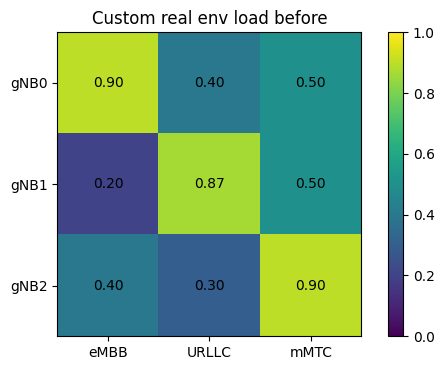

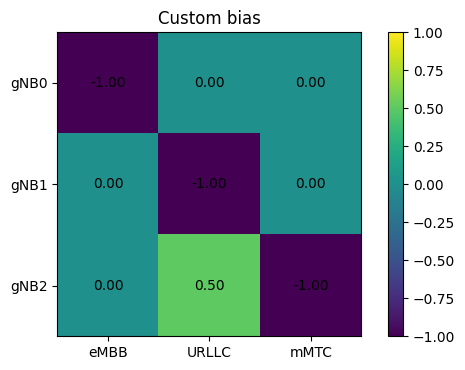

,source,target,slice,bias,proto_offset_db,applied_offset_db,bias_term_db,safety_term_db,neighbor_ue_fraction
0,gNB0,gNB1,URLLC,0.0,2.50,2.0,0.0,3.333333,1.000000
1,gNB0,gNB1,eMBB,-1.0,-4.50,-4.0,-6.0,0.000000,0.333333
2,gNB0,gNB1,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667
3,gNB0,gNB2,URLLC,0.0,0.00,0.0,0.0,0.000000,0.333333
4,gNB0,gNB2,eMBB,-1.0,-4.50,-4.0,-6.0,0.000000,0.333333
5,gNB0,gNB2,mMTC,0.0,2.70,2.0,0.0,3.600000,1.000000
6,gNB1,gNB0,URLLC,-1.0,-4.50,-4.0,-6.0,0.000000,0.333333
7,gNB1,gNB0,eMBB,0.0,2.70,2.0,0.0,3.600000,1.000000
8,gNB1,gNB0,mMTC,0.0,0.10,0.0,0.0,0.133333,0.666667
9,gNB1,gNB2,URLLC,-1.0,-4.50,-4.0,-6.0,0.000000,0.333333


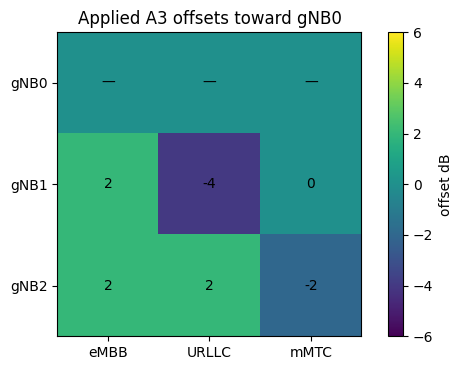

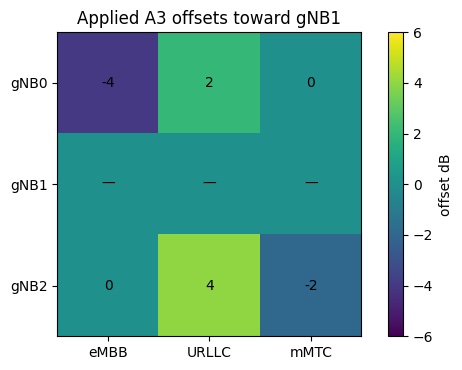

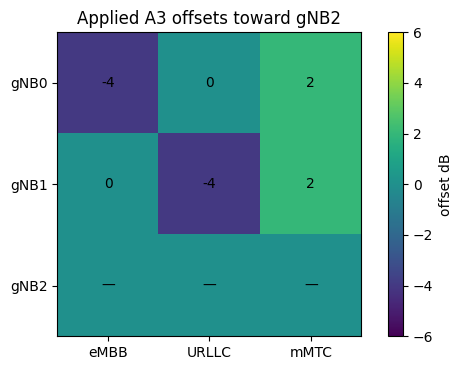

Reward: -4.325319821901064
Info handover_count: 9

Load after


,eMBB,URLLC,mMTC
gNB0,1.0,1.000000,0.5
gNB1,1.0,0.133333,1.0
gNB2,1.0,1.000000,1.0



UE counts after


,eMBB,URLLC,mMTC
gNB0,3.0,2.0,2.0
gNB1,1.0,1.0,3.0
gNB2,1.0,2.0,2.0



Handover events


,step,ue_id,slice_type,from_gnb,to_gnb,controller
0,0,7,URLLC,1,0,GlobalPPO3GNBEnv
1,0,8,URLLC,1,2,GlobalPPO3GNBEnv
2,0,16,mMTC,2,1,GlobalPPO3GNBEnv
3,1,1,eMBB,0,2,GlobalPPO3GNBEnv
4,1,2,eMBB,0,1,GlobalPPO3GNBEnv
5,3,2,eMBB,1,0,GlobalPPO3GNBEnv
6,4,2,eMBB,0,1,GlobalPPO3GNBEnv
7,7,2,eMBB,1,0,GlobalPPO3GNBEnv
8,7,1,eMBB,2,0,GlobalPPO3GNBEnv


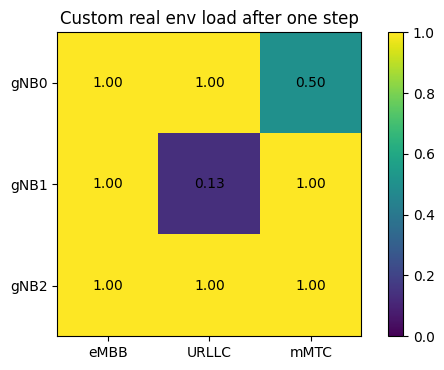

Variance before: 0.1832098765432099
Variance after : 0.22246913580246913


In [6]:

custom_load = np.array([
    [0.90, 0.40, 0.50],
    [0.20, 0.85, 0.50],
    [0.40, 0.30, 0.90],
], dtype=float)

custom_bias = np.array([
    [-1.0,  0.0,  0.0],
    [ 0.0, -1.0,  0.0],
    [ 0.0,  0.5, -1.0],
], dtype=float)

CUSTOM_SCENARIO_NAME = "my_custom_snapshot"
GLOBAL_SNAPSHOT_SCENARIOS[CUSTOM_SCENARIO_NAME] = custom_load.copy()

env = make_env(
    snapshot_scenario=CUSTOM_SCENARIO_NAME,
    seed=21,
    local_steps_per_global=10,
    global_steps_per_episode=8,
)
obs, info = env.reset()

load_before = get_load_matrix(env)
ue_before = get_ue_count_matrix(env)

print("Custom target load")
display(as_df(custom_load))

print("Real initialized load before")
display(as_df(load_before))

print("Custom bias")
display(as_df(custom_bias))

plot_heatmap(load_before, "Custom real env load before", vmin=0, vmax=1)
plot_heatmap(custom_bias, "Custom bias", vmin=-1, vmax=1)

offset_preview = preview_offsets_without_mutation(env, custom_bias)
display(offset_preview)
plot_offset_heatmaps(offset_preview)

start_event_idx = len(getattr(env.base_env, "handover_events", []))
obs, reward, terminated, truncated, info = env.step(flatten_bias(custom_bias))

load_after = get_load_matrix(env)
ue_after = get_ue_count_matrix(env)
events_df = get_recent_handover_events(env, start_idx=start_event_idx)

print("Reward:", reward)
print("Info handover_count:", info.get("handover_count"))

print("\nLoad after")
display(as_df(load_after))

print("\nUE counts after")
display(as_df(ue_after))

print("\nHandover events")
display(events_df)

plot_heatmap(load_after, "Custom real env load after one step", vmin=0, vmax=1)

print("Variance before:", load_variance(load_before))
print("Variance after :", load_variance(load_after))



## 7. Sweep many load/bias matrices in the real env

This section loops over several custom matrices and reports whether the real env improves load variance, how many handovers happen, and what final load is reached.


In [7]:

TEST_CASES = {
    "embb_g0_offload_manual": {
        "load": np.array([
            [0.88, 0.50, 0.50],
            [0.18, 0.50, 0.50],
            [0.48, 0.50, 0.50],
        ], dtype=float),
        "bias": np.array([
            [-1.0, 0.0, 0.0],
            [ 1.0, 0.0, 0.0],
            [ 0.0, 0.0, 0.0],
        ], dtype=float),
    },
    "neighbors_already_loaded": {
        "load": np.array([
            [0.90, 0.50, 0.50],
            [0.72, 0.50, 0.50],
            [0.80, 0.50, 0.50],
        ], dtype=float),
        "bias": np.array([
            [-1.0, 0.0, 0.0],
            [ 0.0, 0.0, 0.0],
            [ 0.0, 0.0, 0.0],
        ], dtype=float),
    },
    "multi_slice_conflict": {
        "load": np.array([
            [0.92, 0.86, 0.35],
            [0.32, 0.90, 0.88],
            [0.76, 0.30, 0.28],
        ], dtype=float),
        "bias": np.array([
            [-1.0, -1.0,  0.0],
            [ 0.0, -1.0, -1.0],
            [-0.5,  0.5,  0.5],
        ], dtype=float),
    },
    "all_neutral": {
        "load": np.array([
            [0.55, 0.50, 0.50],
            [0.50, 0.55, 0.50],
            [0.50, 0.50, 0.55],
        ], dtype=float),
        "bias": np.zeros((3, 3), dtype=float),
    },
}

def run_real_case(case_name, load_matrix, bias_matrix, seed=100, n_steps=5):
    scenario_key = f"custom_{case_name}"
    GLOBAL_SNAPSHOT_SCENARIOS[scenario_key] = np.asarray(load_matrix, dtype=float).copy()

    env = make_env(
        snapshot_scenario=scenario_key,
        seed=seed,
        local_steps_per_global=10,
        global_steps_per_episode=max(n_steps, 2) + 1,
    )
    obs, info = env.reset()

    initial_load = get_load_matrix(env).copy()
    initial_var = load_variance(initial_load)
    initial_overload = overload_count(initial_load)

    handovers_total = 0
    rewards = []

    for t in range(n_steps):
        obs, reward, terminated, truncated, info = env.step(flatten_bias(bias_matrix))
        rewards.append(float(reward))
        handovers_total += int(info.get("handover_count", 0))
        if terminated or truncated:
            break

    final_load = get_load_matrix(env).copy()
    final_var = load_variance(final_load)
    final_overload = overload_count(final_load)

    return {
        "case": case_name,
        "initial_variance": initial_var,
        "final_variance": final_var,
        "variance_delta": final_var - initial_var,
        "initial_overload_count": initial_overload,
        "final_overload_count": final_overload,
        "handover_total": handovers_total,
        "mean_reward": float(np.mean(rewards)) if rewards else 0.0,
        "initial_load": initial_load,
        "final_load": final_load,
    }

summary_rows = []
case_results = {}

for idx, (case_name, case) in enumerate(TEST_CASES.items()):
    result = run_real_case(
        case_name=case_name,
        load_matrix=case["load"],
        bias_matrix=case["bias"],
        seed=200 + idx,
        n_steps=5,
    )
    case_results[case_name] = result
    summary_rows.append({
        k: v for k, v in result.items()
        if k not in {"initial_load", "final_load"}
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

for case_name, result in case_results.items():
    print("\n" + "=" * 80)
    print(case_name)
    print("Initial load")
    display(as_df(result["initial_load"]))
    print("Final load")
    display(as_df(result["final_load"]))


[GlobalPPO scenario] custom_embb_g0_offload_manual targets=[[0.88, 0.5, 0.5], [0.18, 0.5, 0.5], [0.48, 0.5, 0.5]]
[GlobalPPO scenario] custom_neighbors_already_loaded targets=[[0.9, 0.5, 0.5], [0.72, 0.5, 0.5], [0.8, 0.5, 0.5]]
[GlobalPPO scenario] custom_multi_slice_conflict targets=[[0.92, 0.86, 0.35], [0.32, 0.9, 0.88], [0.76, 0.3, 0.28]]
[GlobalPPO scenario] custom_all_neutral targets=[[0.55, 0.5, 0.5], [0.5, 0.55, 0.5], [0.5, 0.5, 0.55]]


,case,initial_variance,final_variance,variance_delta,initial_overload_count,final_overload_count,handover_total,mean_reward
0,embb_g0_offload_manual,0.082222,0.246163,0.163941,1,5,4,0.447271
1,neighbors_already_loaded,0.005422,0.194973,0.189551,1,6,3,-0.232657
2,multi_slice_conflict,0.214047,0.268089,0.054042,4,7,44,-0.488993
3,all_neutral,0.001602,0.134607,0.133005,0,5,0,1.166748



embb_g0_offload_manual
Initial load


,eMBB,URLLC,mMTC
gNB0,0.88,0.5,0.5
gNB1,0.18,0.5,0.5
gNB2,0.48,0.5,0.5


Final load


...

,eMBB,URLLC,mMTC
gNB0,1.00,1.0,0.4
gNB1,0.08,1.0,1.0
gNB2,1.00,1.0,1.0



all_neutral
Initial load


,eMBB,URLLC,mMTC
gNB0,0.56,0.500000,0.50
gNB1,0.50,0.533333,0.50
gNB2,0.50,0.500000,0.55


Final load


,eMBB,URLLC,mMTC
gNB0,1.00,1.000000,0.5
gNB1,0.68,0.466667,1.0
gNB2,1.00,0.533333,1.0



## 8. Radio-level diagnostic: check received powers for current UEs

This cell reads a few UEs from the real `MultiGNBWrapper` and prints the received power from every gNB.
This verifies that the handover decisions are based on the real radio model, not the toy load model.


In [8]:

# Use the last env from the previous section, or create a fresh one if needed.
try:
    env
except NameError:
    env = make_env(snapshot_scenario="embb_g0_offload", seed=9)
    obs, info = env.reset()

ues = list(env.base_env.get_all_ues())
rows = []

for ue in ues[:12]:
    row = {
        "ue_id": int(ue.id),
        "slice": getattr(ue, "slice_type", None),
        "serving_gnb": int(ue.serving_gnb) if ue.serving_gnb is not None else None,
        "x": float(ue.x),
        "y": float(ue.y),
    }

    for gnb in env.base_env.gnbs:
        try:
            rx = env.base_env._compute_link_metrics(gnb, ue)["rx_power_dbm"]
        except Exception:
            rx = np.nan
        row[f"rx_gNB{int(gnb.id)}_dBm"] = float(rx)

    rows.append(row)

radio_df = pd.DataFrame(rows)
display(radio_df)


,ue_id,slice,serving_gnb,x,y,rx_gNB0_dBm,rx_gNB1_dBm,rx_gNB2_dBm
0,0,eMBB,0,39.024872,165.000613,-73.982625,-89.660412,-82.854125
1,1,eMBB,0,188.529986,138.161028,-79.224770,-83.066316,-80.612438
2,2,eMBB,0,206.646396,39.818433,-77.510983,-80.099019,-85.848586
3,3,URLLC,0,87.105348,-141.380503,-73.642686,-87.562266,-100.000000
4,4,mMTC,0,6.583770,-196.771944,-76.422912,-100.000000,-100.000000
5,5,mMTC,0,35.685078,97.253976,-65.937375,-89.010313,-85.753508
6,6,eMBB,1,352.553106,-184.239981,-87.907807,-77.353140,-100.000000
7,7,URLLC,0,219.501957,-17.860974,-78.252726,-79.045928,-88.317501
8,8,URLLC,2,438.889456,250.508831,-100.000000,-80.372552,-80.669428
9,9,URLLC,1,257.033755,-90.543984,-81.731456,-77.719556,-100.000000



# Interpretation guide

Look at these outputs:

1. **Bias matrix**
   - negative means the serving gNB-slice wants to offload
   - positive means it wants to retain

2. **Offset preview**
   - negative applied offset means A3 handover becomes easier
   - positive applied offset means A3 handover becomes harder

3. **Handover events**
   - real movement of UEs between gNBs

4. **Load before/after**
   - this is the real environment load after real A3-based handovers and real radio evaluation

5. **Variance**
   - if variance decreases, the load is becoming more balanced
   - if variance increases or neighbors saturate, the heuristic is too aggressive or not load-aware enough
